# **Decripcion del Dataset**
Descripción:

Este conjunto de datos reúne información relacionada con usuarios, preferencias turísticas e interacciones dentro de un contexto de recomendación de viajes. Su propósito es apoyar el desarrollo y evaluación de sistemas de recomendación personalizados, permitiendo analizar cómo las características del usuario, su comportamiento y el contexto del viaje influyen en la sugerencia de destinos, actividades o experiencias turísticas.

Fuente: Kaggle: https://www.kaggle.com/datasets/lucasbrownkk/tourism-recommendation-dataset

Cada fila representa una interacción o registro asociado a un usuario dentro de un sistema de recomendación turística. El dataset incluye información sobre perfiles de usuario, comportamiento de interacción y variables contextuales, lo que permite estudiar distintos enfoques de recomendación, como filtrado colaborativo, modelos híbridos, factorización matricial y métodos basados en aprendizaje automático.

Variables principales:

ID de usuario
Características demográficas del usuario
Perfil o preferencias del viajero
Historial de interacción
Destino, lugar o actividad turística recomendada
Temporada del viaje
Estado de vacaciones
Tipo de viaje: grupal o independiente
Características contextuales del viaje
Preferencias o comportamiento turístico
Información para recomendación personalizada

Estos datos permiten investigar cómo entregar recomendaciones turísticas más ajustadas a cada usuario, considerando tanto su perfil personal como su comportamiento previo y el contexto del viaje. Además, pueden utilizarse para entrenar y evaluar modelos de recomendación mediante filtrado colaborativo, estrategias híbridas y técnicas de aprendizaje automático.

El conjunto de datos contiene 100.000 registros correspondientes a 10.000 usuarios.



### **Importación de Librerías**

In [1]:
# Importamos pandas para el manejo de tablas (DataFrames)
import pandas as pd

# Importamos numpy para operaciones matemáticas y manejo de valores nulos
import numpy as np

# Importamos matplotlib y seaborn para las visualizaciones y gráficos
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

### **Carga del Conjunto de Datos**

In [2]:
# Cargamos el dataset indicando el nombre exacto del archivo
df = pd.read_csv('C:/Users/yuril/OneDrive/Escritorio/Proyectos skillnest cientifico de datos/Proyecto 2 – Parte I (Core)/dataset/tourism_recommendation_dataset_en.csv')

# Primeros 5 registros del conjunto de datos
df.head()

,tourist_id,gender,age,age_group,source_province,attraction_name,attraction_category,attraction_level,city,province,...,rating,is_group_tour,group_fee,trip_days,main_spots,transport_mode,season,is_holiday,recommendation_level,satisfaction_level
0,1,Female,67,56+,Beijing,Xuan Kong Si,Religious Culture,4A,Da Tong Shi,Shanxi,...,4.3,No,NaN,NaN,NaN,NaN,Winter,No,Recommend,Satisfied
1,2,Male,22,18-25,Heilongjiang,Kai Feng Fu,Historical Culture,4A,Kai Feng Shi,Henan,...,4.8,No,NaN,NaN,NaN,NaN,Autumn,No,Highly Recommend,Very Satisfied
2,3,Male,60,56+,Fujian,Zhou Zhuang Gu Zhen,Ancient Town,5A,Su Zhou Shi,Jiangsu,...,4.4,No,NaN,NaN,NaN,NaN,Summer,No,Recommend,Satisfied
3,4,Female,33,26-35,Ningxia,Zhu Jia Jiao Gu Zhen,Ancient Town,4A,Shanghai,Shanghai,...,3.7,No,NaN,NaN,NaN,NaN,Autumn,No,Recommend,Satisfied
4,5,Female,59,56+,Jiangxi,Lu Shan,Natural Culture,5A,Jiu Jiang Shi,Jiangxi,...,4.9,No,NaN,NaN,NaN,NaN,Winter,No,Highly Recommend,Very Satisfied


### **Dimensiones del Dataset**

In [3]:
# df.shape devuelve una tupla: (filas, columnas)
df.shape

(100000, 25)

In [ ]:
filas, columnas = df.shape

print("Cantidad de filas:", filas)
print("Cantidad de columnas:", columnas)

#El dataset contiene 100.000 registros y 25 columnas. Cada fila representa una visita turística o interacción de un turista con una atracción. Las columnas describen características del turista, información de la atracción, comportamiento de gasto, duración de la visita y nivel de recomendación.

Cantidad de filas: 100000
Cantidad de columnas: 25


### **Tipos de Datos y Estructura Básica**

In [5]:
# Muestra un resumen del tipo de datos por columna y la memoria utilizada
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   tourist_id            100000 non-null  int64  
 1   gender                100000 non-null  str    
 2   age                   100000 non-null  int64  
 3   age_group             100000 non-null  str    
 4   source_province       100000 non-null  str    
 5   attraction_name       100000 non-null  str    
 6   attraction_category   100000 non-null  str    
 7   attraction_level      100000 non-null  str    
 8   city                  100000 non-null  str    
 9   province              100000 non-null  str    
 10  ticket_price          100000 non-null  int64  
 11  visit_date            100000 non-null  str    
 12  visit_duration_hours  100000 non-null  float64
 13  spend_amount          100000 non-null  float64
 14  other_spend           100000 non-null  float64
 15  rating      

El dataset contiene variables numéricas y categóricas. 
Las variables numéricas incluyen edad, precio de entrada, duración de la visita, gasto total, gasto adicional, rating, tarifa de viaje grupal y días de viaje.

Las variables categóricas incluyen género, grupo etario, provincia de origen, nombre de atracción, categoría de atracción, nivel de atracción, ciudad, provincia, fecha de visita, tipo de viaje, medio de transporte, temporada, feriado, nivel de recomendación y nivel de satisfacción.

#### **Revision nombres de columnas**

In [7]:
df.columns
#Se revisan los nombres de las columnas para identificar las variables disponibles y comprender mejor la estructura del dataset antes de iniciar el análisis exploratorio.


Index(['tourist_id', 'gender', 'age', 'age_group', 'source_province',
       'attraction_name', 'attraction_category', 'attraction_level', 'city',
       'province', 'ticket_price', 'visit_date', 'visit_duration_hours',
       'spend_amount', 'other_spend', 'rating', 'is_group_tour', 'group_fee',
       'trip_days', 'main_spots', 'transport_mode', 'season', 'is_holiday',
       'recommendation_level', 'satisfaction_level'],
      dtype='str')

In [8]:
# Convertimos la columna visit_date a formato fecha
df["visit_date"] = pd.to_datetime(df["visit_date"])

# Verificamos el cambio
df["visit_date"].head()

0   2023-12-25
1   2024-11-14
2   2022-07-20
3   2024-09-19
4   2024-12-31
Name: visit_date, dtype: datetime64[us]

In [9]:
print("Fecha mínima:", df["visit_date"].min())
print("Fecha máxima:", df["visit_date"].max())

Fecha mínima: 2022-05-04 00:00:00
Fecha máxima: 2025-05-03 00:00:00


La columna `visit_date` se convierte a formato fecha para facilitar futuros análisis temporales. 
El dataset contiene visitas entre el 04 de mayo de 2022 y el 03 de mayo de 2025.

#### **Separacion de variables numéricas y categóricas**

In [11]:
columnas_numericas = df.select_dtypes(include=np.number).columns
columnas_categoricas = df.select_dtypes(include="object").columns

print("Variables numéricas:")
print(columnas_numericas)

print("Variables categóricas:")
print(columnas_categoricas)

Variables numéricas:
Index(['tourist_id', 'age', 'ticket_price', 'visit_duration_hours',
       'spend_amount', 'other_spend', 'rating', 'group_fee', 'trip_days'],
      dtype='str')
Variables categóricas:
Index(['gender', 'age_group', 'source_province', 'attraction_name',
       'attraction_category', 'attraction_level', 'city', 'province',
       'is_group_tour', 'main_spots', 'transport_mode', 'season', 'is_holiday',
       'recommendation_level', 'satisfaction_level'],
      dtype='str')


Se separan las variables numéricas y categóricas para facilitar el análisis. 
Las variables numéricas serán utilizadas para estadísticas descriptivas, histogramas, boxplots y correlaciones. 
Las variables categóricas serán analizadas mediante frecuencias y gráficos de barras.

### **Análisis Estadístico Descriptivo**

### **Variables Numéricas**

In [12]:
# Estadísticas descriptivas para variables numéricas
df.describe().T


,count,mean,min,25%,50%,75%,max,std
tourist_id,100000.0,4747.80608,1.0,2278.0,4660.0,7150.0,10000.0,2835.294544
age,100000.0,44.23139,18.0,31.0,44.0,57.0,70.0,15.256722
ticket_price,100000.0,80.78351,0.0,35.0,70.0,115.0,399.0,67.183866
visit_date,100000,2023-11-03 07:35:35.231999,2022-05-04 00:00:00,2023-02-02 00:00:00,2023-11-04 00:00:00,2024-08-03 00:00:00,2025-05-03 00:00:00,NaN
visit_duration_hours,100000.0,4.500496,1.0,2.7,4.5,6.3,8.0,2.021727
spend_amount,100000.0,255.433621,0.0,98.0,227.2,401.09,898.22,179.814679
other_spend,100000.0,174.650111,0.0,0.0,141.88,320.97,500.0,166.584179
rating,100000.0,4.431909,3.1,4.2,4.4,4.7,5.0,0.36068
group_fee,29758.0,3045.056993,501.0,1234.0,2317.0,4689.0,7946.0,2154.450339
trip_days,29758.0,3.994321,1.0,2.0,4.0,6.0,7.0,2.013298


El análisis descriptivo permite observar medidas como media, desviación estándar, valor mínimo, valor máximo y cuartiles.

En este dataset, la edad promedio de los turistas es cercana a 44 años. 
El precio promedio de entrada es de aproximadamente 81, aunque existen atracciones gratuitas y otras con precios cercanos a 399. 
La duración promedio de visita es cercana a 4,5 horas. 
El rating promedio es alto, cercano a 4,43 sobre 5.
| Variable               | Comentario                                                |
| ---------------------- | --------------------------------------------------------- |
| `age`                  | Edad entre 18 y 70 años, promedio cercano a 44 años.      |
| `ticket_price`         | Precio entre 0 y 399, promedio cercano a 81.              |
| `visit_duration_hours` | Duración entre 1 y 8 horas, promedio cercano a 4,5 horas. |
| `spend_amount`         | Gasto total promedio cercano a 255.                       |
| `other_spend`          | Gasto adicional promedio cercano a 175.                   |
| `rating`               | Rating entre 3,1 y 5, con promedio cercano a 4,43.        |
| `group_fee`            | Solo aplica a viajes grupales.                            |
| `trip_days`            | Solo aplica a viajes grupales.                            |


### **Variables Categóricas**

In [13]:
# Distribución de variables categóricas
df.describe(include='object').T

,count,unique,top,freq
gender,100000,2,Female,50161
age_group,100000,5,56+,28482
source_province,100000,34,Henan,3353
attraction_name,100000,431,Hu Kou Pu Bu,452
attraction_category,100000,26,Natural Scenery,36347
attraction_level,100000,3,4A,52383
city,100000,217,Shanghai,4693
province,100000,22,Zhejiang,4767
is_group_tour,100000,2,No,70242
main_spots,29758,500,"Gu Bei Shui Zhen , Huang Shan , Shou Xi Hu ,...",82


Las variables categóricas permiten conocer la distribución de los grupos dentro del dataset. 
En este caso se analizan variables como género, grupo etario, provincia de origen, nombre de atracción, categoría, nivel turístico, ciudad, provincia, tipo de viaje, transporte, temporada, feriado, recomendación y satisfacción.

#### **Revision valores variable categóricas**

In [14]:
# Revisamos los valores únicos y sus frecuencias
for col in columnas_categoricas:
    print("\nColumna:", col)
    print("Cantidad de valores únicos:", df[col].nunique())
    print(df[col].value_counts().head(10))


Columna: gender
Cantidad de valores únicos: 2
gender
Female    50161
Male      49839
Name: count, dtype: int64

Columna: age_group
Cantidad de valores únicos: 5
age_group
56+      28482
46-55    19440
36-45    18920
26-35    18270
18-25    14888
Name: count, dtype: int64

Columna: source_province
Cantidad de valores únicos: 34
source_province
Henan        3353
Hunan        3240
Guangdong    3201
Jiangsu      3164
Tibet        3160
Anhui        3152
Tianjin      3134
Shaanxi      3114
Zhejiang     3083
Hainan       3076
Name: count, dtype: int64

Columna: attraction_name
Cantidad de valores únicos: 431
attraction_name
Hu Kou Pu Bu                       452
Bai Yun Shan                       445
Wu Xi Ying Shi Ji Di               274
Shang Hai Chen Shan Zhi Wu Yuan    265
Ling Shan Da Fu                    265
Wu Zhen                            265
Gu Bei Shui Zhen                   265
Ha Er Bin Bing Xue Da Shi Jie      262
Zhong Nan Shan                     260
Huang Shan             

Se revisan los valores únicos de cada variable categórica para detectar posibles errores de escritura, categorías duplicadas, valores extraños o categorías poco frecuentes.
El dataset contiene muchas categorías, especialmente en variables como `attraction_name`, `city`, `province` y `main_spots`. 
Esto es normal en un dataset turístico, porque existen muchas atracciones, ciudades y lugares visitados.

También se observa que la variable `season` contiene una categoría llamada `Chun Ji`, que corresponde a primavera en chino romanizado. Para mantener consistencia con las otras categorías en inglés, se puede reemplazar por `Spring`.

Además, algunas categorías de `attraction_category` aparecen en inglés y otras en formato romanizado, como `Zi Ran Qi Guan` o `Wen Hua Yi Shu`. Esto no necesariamente es un error, pero sí representa un desafío de limpieza y estandarización.

### **Detección y Corrección de Incongruencias Categóricas**
Se realizó una auditoría de las principales variables categóricas del dataset con el objetivo de identificar posibles inconsistencias en los valores.

Este proceso permite revisar si existen categorías repetidas con diferencias de escritura, uso de mayúsculas o minúsculas, espacios adicionales o valores mal registrados.

Esta revisión es importante porque las variables categóricas deben estar correctamente estandarizadas antes de realizar análisis más profundos o aplicar modelos de machine learning.

In [15]:
# Le decimos a pandas que no recorte el contenido de las columnas
pd.set_option("display.max_colwidth", None)

# Definimos las columnas categóricas principales que queremos revisar
columnas_objetivo = [
    "gender",
    "age_group",
    "attraction_category",
    "attraction_level",
    "is_group_tour",
    "transport_mode",
    "season",
    "is_holiday",
    "recommendation_level",
    "satisfaction_level"
]

# Creamos una lista para guardar el diagnóstico
lista_resumen = []

for col in columnas_objetivo:
    if col in df.columns:
        cantidad_unicos = df[col].nunique(dropna=False)
        todos_los_valores = df[col].dropna().unique().tolist()
        
        lista_resumen.append({
            "Columna": col,
            "Cantidad de valores únicos": cantidad_unicos,
            "Valores encontrados": todos_los_valores
        })

# Convertimos la lista en DataFrame
resumen_categoricas = pd.DataFrame(lista_resumen)

resumen_categoricas

,Columna,Cantidad de valores únicos,Valores encontrados
0,gender,2,"[Female, Male]"
1,age_group,5,"[56+, 18-25, 26-35, 46-55, 36-45]"
2,attraction_category,26,"[Religious Culture, Historical Culture, Ancient Town, Natural Culture, Revolutionary Site, Sports & Leisure, Natural Scenery, Botanical Garden, Theme Park, Historical Site, Urban Landscape, Zi Ran Qi Guan, Wen Hua Yi Shu, Historical Architecture, Cheng Shi Gong Yuan, Min Su Wen Hua, Food Street, Zoo, Wen Bo Yuan Guan, Urban Landmark, Ke Pu Jiao Yu, Gong Ye Lv You, Shui Zu Guan, Shui Li Gong Cheng, Zhu Ti Zhan Lan, Wen Hua Lv You]"
3,attraction_level,3,"[4A, 5A, 3A]"
4,is_group_tour,2,"[No, Yes]"
5,transport_mode,4,"[Gao Tie + Da Ba, Fei Ji + Da Ba, Kong Tiao Da Ba]"
6,season,4,"[Winter, Autumn, Summer, Chun Ji]"
7,is_holiday,2,"[No, Yes]"
8,recommendation_level,3,"[Recommend, Highly Recommend, Neutral]"
9,satisfaction_level,3,"[Satisfied, Very Satisfied, Neutral]"


In [16]:
# Reemplazamos Chun Ji por Spring para mantener consistencia en inglés
df["season"] = df["season"].replace("Chun Ji", "Spring")

# Verificamos nuevamente los valores de season
df["season"].value_counts()

season
Summer    25196
Spring    25099
Autumn    25091
Winter    24614
Name: count, dtype: int64

Se detectó que la variable `season` contiene la categoría `Chun Ji`, que corresponde a primavera. 
Como las demás estaciones están escritas en inglés, se reemplaza `Chun Ji` por `Spring` para mantener consistencia en el idioma de las categorías.

### **Identificación de Valores Nulos, Duplicados y Outliers**

#### **Detección de Valores Nulos**

In [17]:
# Revisamos la cantidad de valores nulos por columna
nulos = df.isnull().sum()

# Calculamos el porcentaje de valores nulos
porcentaje_nulos = df.isnull().mean() * 100

# Creamos una tabla resumen
tabla_nulos = pd.DataFrame({
    "Valores nulos": nulos,
    "Porcentaje (%)": porcentaje_nulos
})

tabla_nulos.sort_values("Valores nulos", ascending=False)

,Valores nulos,Porcentaje (%)
transport_mode,70242,70.242
group_fee,70242,70.242
trip_days,70242,70.242
main_spots,70242,70.242
source_province,0,0.000
gender,0,0.000
age,0,0.000
age_group,0,0.000
tourist_id,0,0.000
city,0,0.000


El dataset presenta valores nulos en las variables `group_fee`, `trip_days`, `main_spots` y `transport_mode`.

Estos valores nulos no parecen ser errores, ya que están relacionados con la variable `is_group_tour`. 
Cuando el turista no realiza un viaje grupal, no tiene sentido que existan datos de tarifa grupal, días de viaje grupal, principales lugares del tour o medio de transporte del tour.

#### **Verificación de Nulos según Tipo de Viaje**

In [18]:
# Revisamos si los valores nulos están relacionados con is_group_tour
pd.crosstab(df["is_group_tour"], df["group_fee"].isnull())

group_fee,False,True
is_group_tour,,
No,0,70242
Yes,29758,0


La tabla cruzada muestra que los valores nulos de `group_fee` aparecen únicamente en turistas que no realizaron viaje grupal. 
Por lo tanto, estos nulos son estructurales y no necesariamente deben eliminarse. 
Representan la ausencia de información porque esa variable no aplica para viajes individuales.

In [19]:
columnas_grupo = ["group_fee", "trip_days", "main_spots", "transport_mode"]

for col in columnas_grupo:
    print("\nColumna:", col)
    print(pd.crosstab(df["is_group_tour"], df[col].isnull()))


Columna: group_fee
group_fee      False  True 
is_group_tour              
No                 0  70242
Yes            29758      0

Columna: trip_days
trip_days      False  True 
is_group_tour              
No                 0  70242
Yes            29758      0

Columna: main_spots
main_spots     False  True 
is_group_tour              
No                 0  70242
Yes            29758      0

Columna: transport_mode
transport_mode  False  True 
is_group_tour               
No                  0  70242
Yes             29758      0


#### **Tratamiento propuesto para valores nulos**

Los valores nulos en `group_fee`, `trip_days`, `main_spots` y `transport_mode` están asociados a turistas que no realizaron viajes grupales. 
Por lo tanto, no se consideran errores de carga.

Para una futura etapa de modelamiento, se podrían tratar de la siguiente manera:

- En `group_fee` y `trip_days`, reemplazar los nulos por 0, ya que no existe tarifa ni duración de viaje grupal para turistas individuales.
- En `main_spots` y `transport_mode`, reemplazar los nulos por una categoría como `No group tour`.
- Mantener la variable `is_group_tour`, porque permite distinguir entre turistas individuales y grupales.

En esta etapa de EDA inicial, los nulos se mantienen y se documenta su causa.

In [20]:
# Creamos una copia para no modificar el DataFrame original directamente
df_limpio = df.copy()

# Reemplazamos nulos numéricos asociados a viajes no grupales
df_limpio["group_fee"] = df_limpio["group_fee"].fillna(0)
df_limpio["trip_days"] = df_limpio["trip_days"].fillna(0)

# Reemplazamos nulos categóricos asociados a viajes no grupales
df_limpio["main_spots"] = df_limpio["main_spots"].fillna("No group tour")
df_limpio["transport_mode"] = df_limpio["transport_mode"].fillna("No group tour")

#### **Identificando Duplicados**

In [21]:
# Identificación de registros duplicados
duplicados = df.duplicated().sum()

print(f"Registros duplicados encontrados: {duplicados}")

if duplicados > 0:
    display(df[df.duplicated()].head())

Registros duplicados encontrados: 0


No se encontraron registros duplicados exactos en el dataset. 
Esto indica que no existen filas completamente repetidas.

Sin embargo, la variable `tourist_id` sí puede repetirse, lo cual no representa un error necesariamente, ya que un mismo turista puede haber realizado varias visitas o interacciones turísticas.

In [22]:
# Cantidad de turistas únicos
df["tourist_id"].nunique()
#Aunque el dataset contiene 100.000 registros, existen 10.000 turistas únicos. 
#Esto indica que algunos turistas aparecen más de una vez, probablemente porque realizaron distintas visitas.

10000

### **Visualizaciones**

#### **Histogramas de variables numéricas**

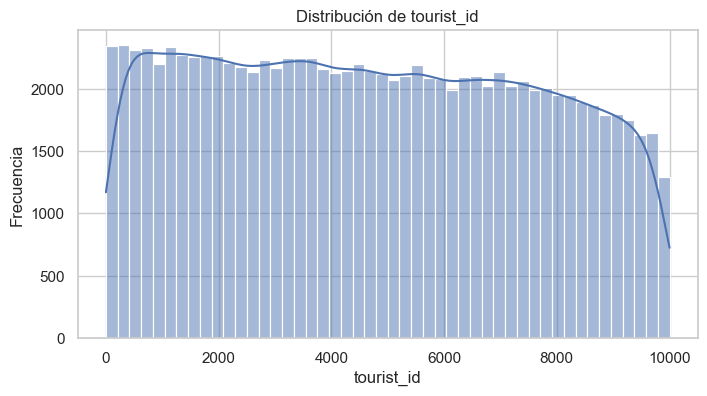

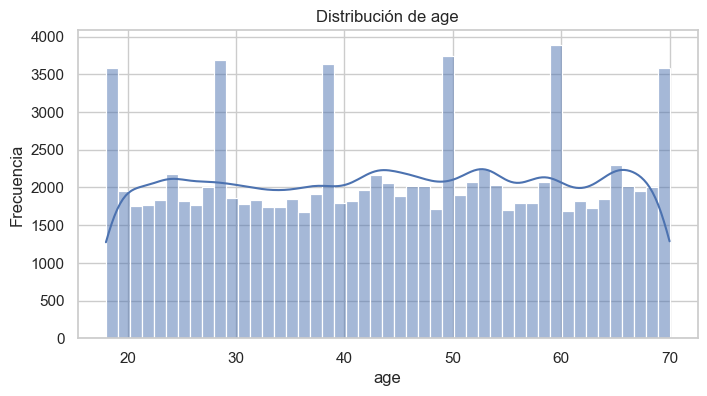

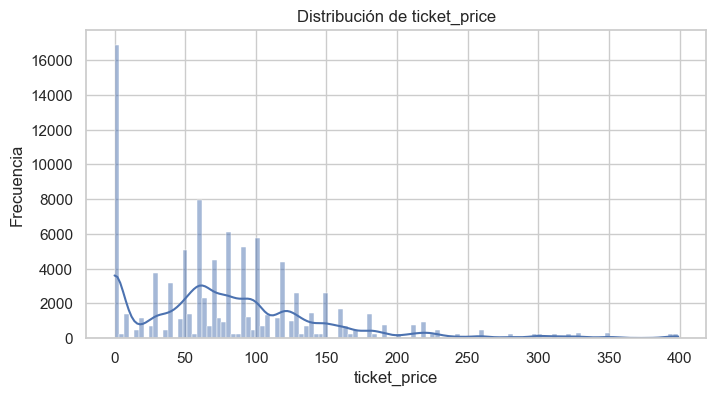

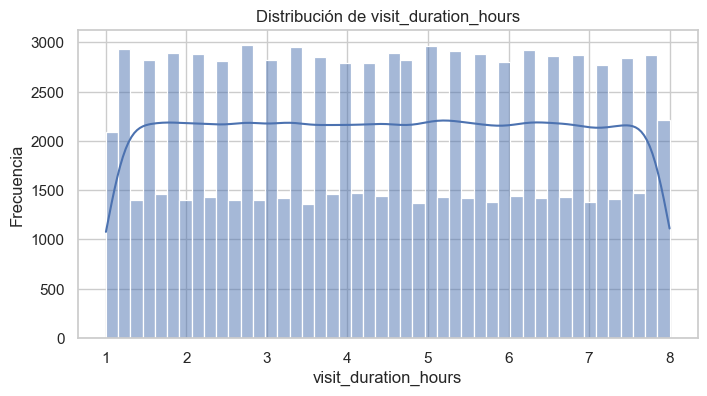

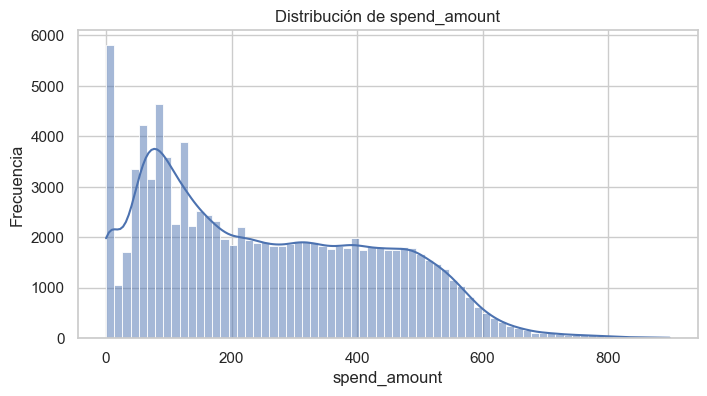

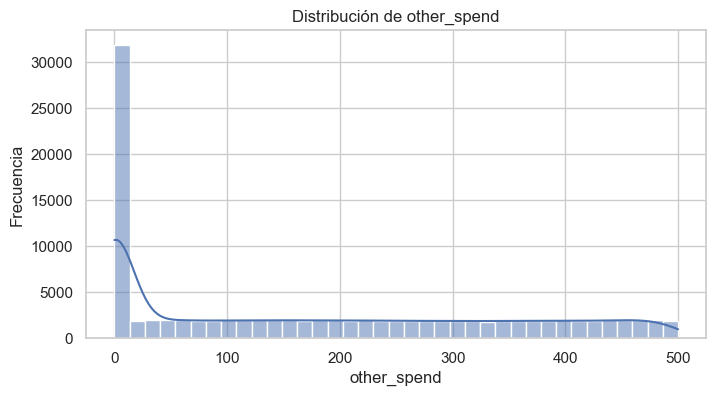

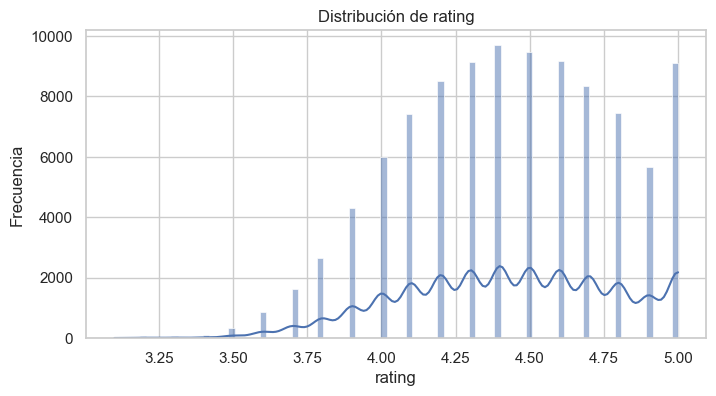

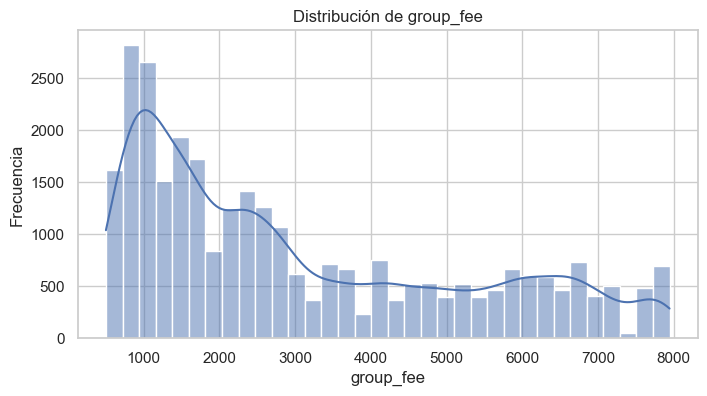

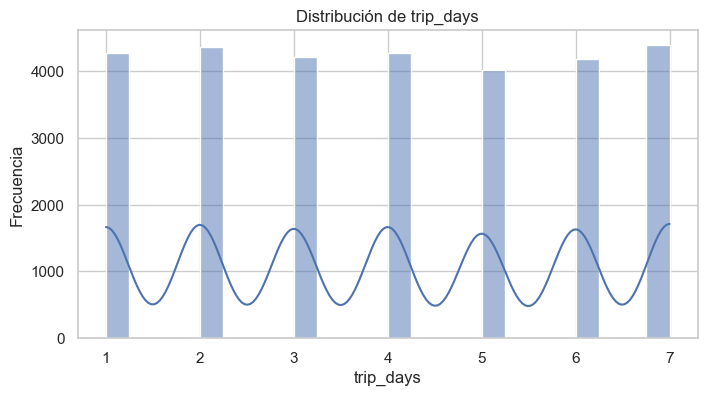

In [23]:
for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

Los histogramas permiten observar la distribución de las variables numéricas. 
Se observa que la edad se distribuye entre 18 y 70 años, mientras que el rating se concentra en valores altos, principalmente entre 4 y 5. 
El gasto total y el precio de entrada presentan mayor concentración en valores bajos y medios, con algunos valores más altos.

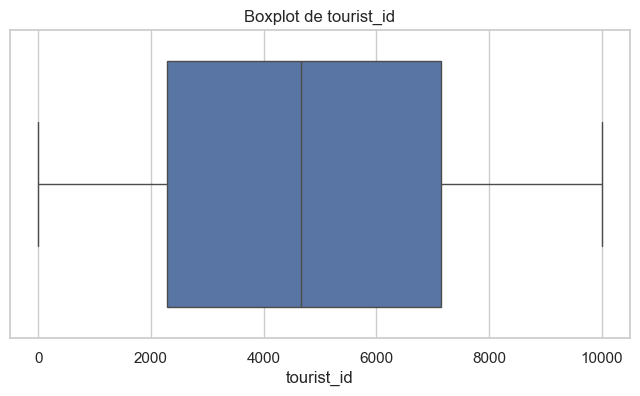

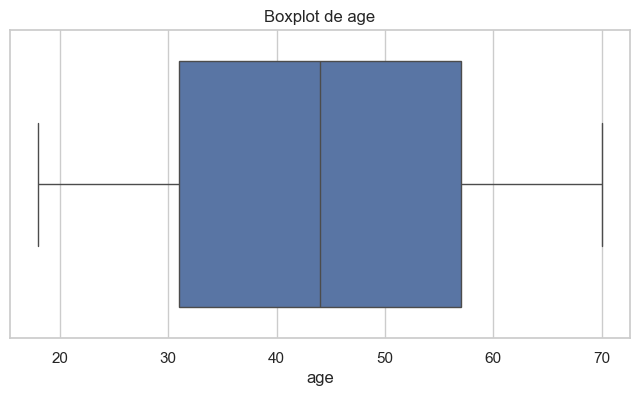

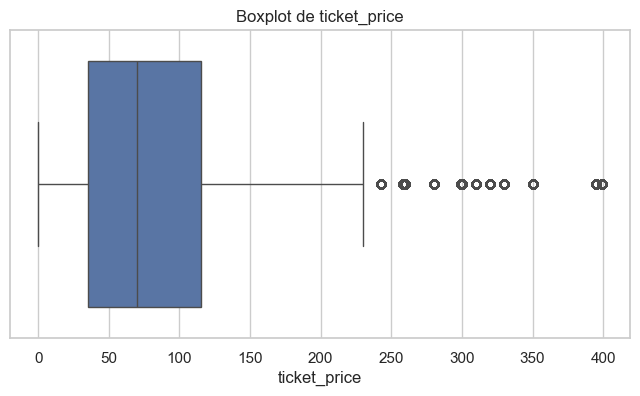

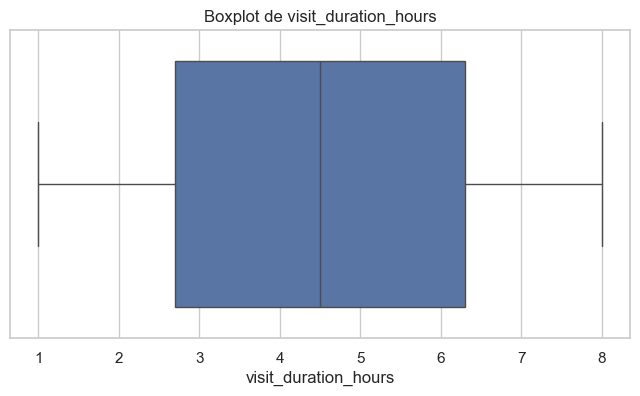

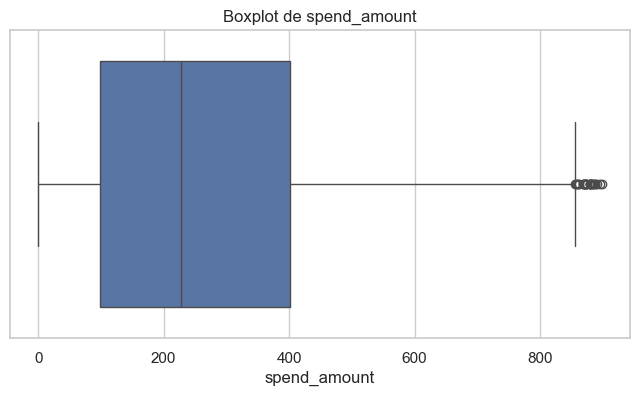

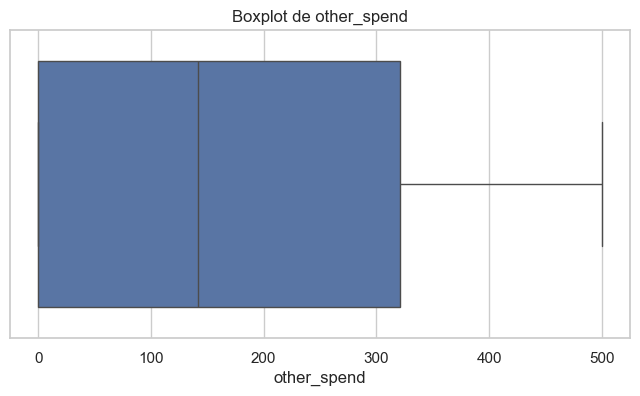

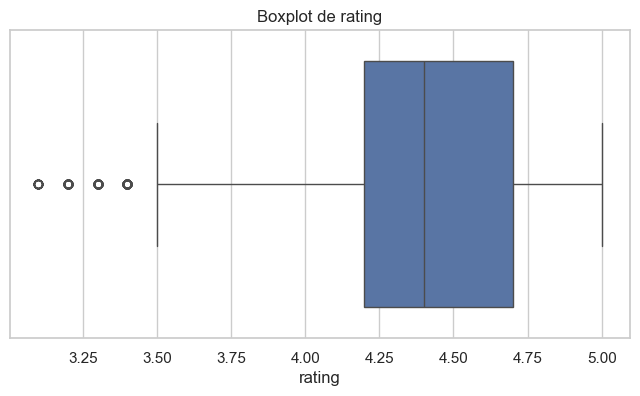

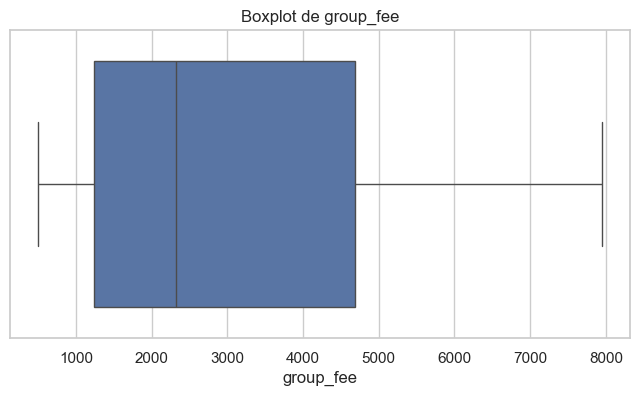

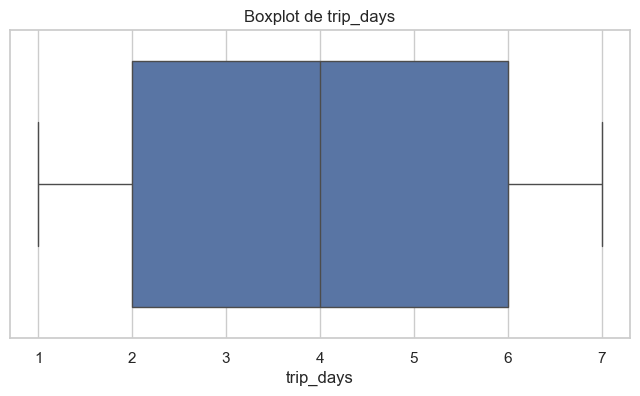

In [24]:
# Boxplots para revisar posibles outliers
for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

Los boxplots permiten identificar visualmente posibles valores atípicos. 
En este dataset se observan posibles outliers principalmente en `ticket_price`, `spend_amount` y `rating`.

Estos valores no deben eliminarse automáticamente. 
Por ejemplo, un precio de entrada alto puede corresponder a una atracción turística premium, mientras que un rating bajo puede representar una experiencia menos satisfactoria.

### **Identificando Outliers**

La revisión de valores atípicos (outliers) es importante porque pueden distorsionar el análisis estadístico y afectar el rendimiento de algunos modelos de machine learning. Algoritmos como la regresión lineal, K-Means o KNN son especialmente sensibles a estos valores extremos, mientras que los modelos basados en árboles suelen ser más robustos. Por ello, es recomendable identificarlos y evaluar si corresponden a errores o a comportamientos reales de los datos.

In [25]:
# Detección de outliers usando el método del rango intercuartílico
resumen_outliers = []

for col in columnas_numericas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    
    resumen_outliers.append({
        "Variable": col,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Cantidad de outliers": outliers.shape[0],
        "Porcentaje de outliers": round((outliers.shape[0] / df.shape[0]) * 100, 2)
    })

tabla_outliers = pd.DataFrame(resumen_outliers)

tabla_outliers

,Variable,Límite inferior,Límite superior,Cantidad de outliers,Porcentaje de outliers
0,tourist_id,-5030.000,14458.000,0,0.00
1,age,-8.000,96.000,0,0.00
2,ticket_price,-85.000,235.000,2888,2.89
3,visit_duration_hours,-2.700,11.700,0,0.00
4,spend_amount,-356.635,855.725,27,0.03
5,other_spend,-481.455,802.425,0,0.00
6,rating,3.450,5.450,241,0.24
7,group_fee,-3948.500,9871.500,0,0.00
8,trip_days,-4.000,12.000,0,0.00


Se aplica el método IQR para detectar posibles outliers en las variables numéricas.

El IQR corresponde a la diferencia entre el tercer cuartil y el primer cuartil. A partir de este valor se calculan límites inferiores y superiores.

Los valores que quedan fuera de esos límites pueden considerarse posibles outliers.

Se identificaron posibles outliers en algunas variables numéricas. 
La variable `ticket_price` presenta valores superiores al límite esperado según el método IQR, lo que puede corresponder a atracciones de mayor costo. 
La variable `spend_amount` presenta muy pocos valores atípicos, por lo que no parece ser un problema importante. 
En `rating`, los valores más bajos pueden ser detectados como outliers debido a que la mayoría de las evaluaciones son altas.

En general, los outliers encontrados parecen plausibles dentro del contexto turístico y no deberían eliminarse automáticamente.
| Variable       | Outliers aproximados | Porcentaje |
| -------------- | -------------------: | ---------: |
| `ticket_price` |                2.888 |      2,89% |
| `spend_amount` |                   27 |      0,03% |
| `rating`       |                  241 |      0,24% |


#### **Gráficos de barras para variables categóricas**

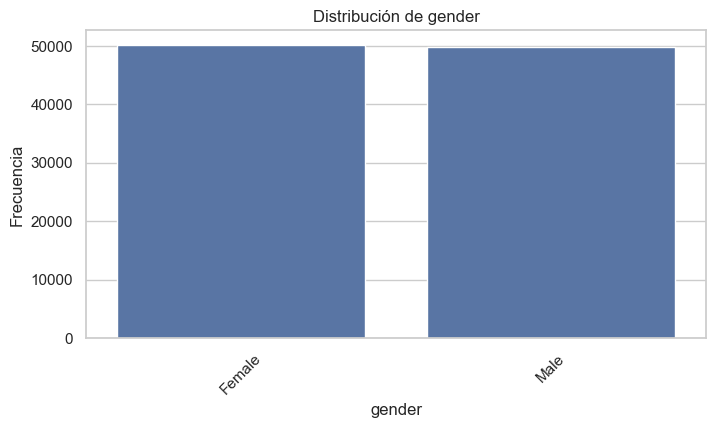

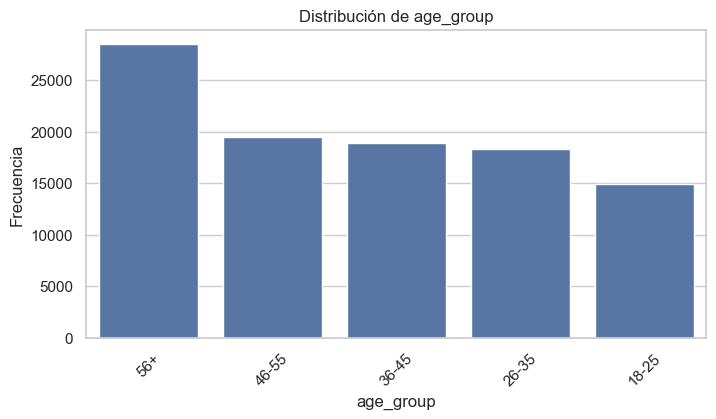

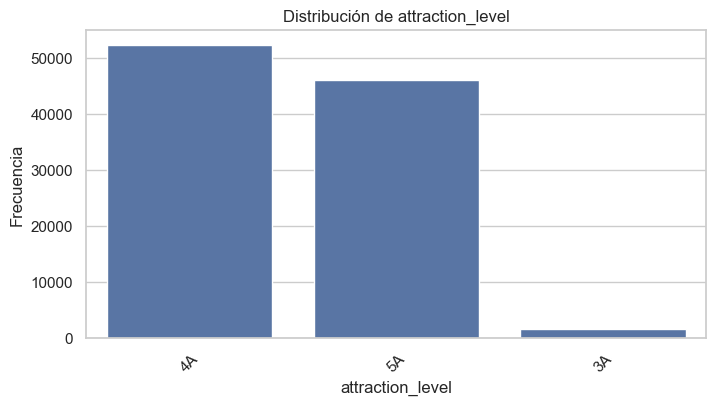

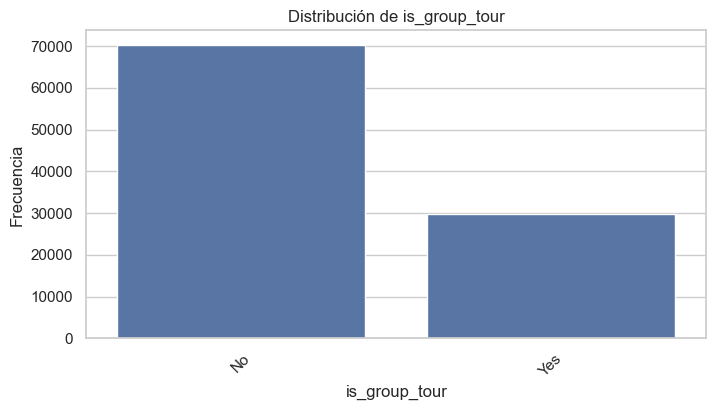

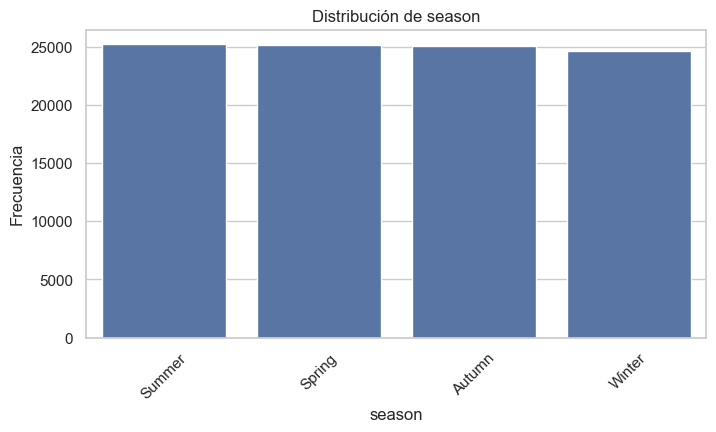

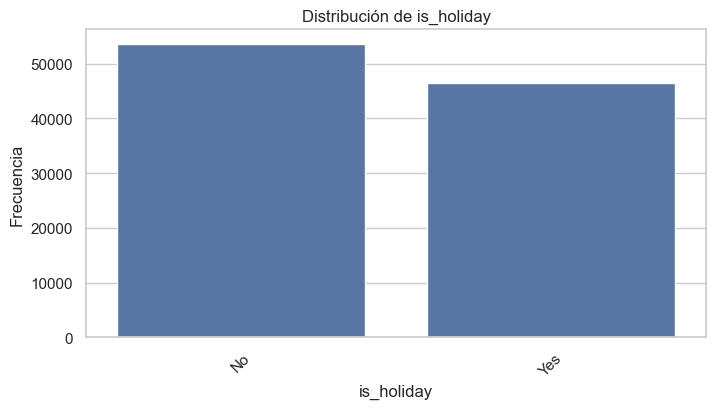

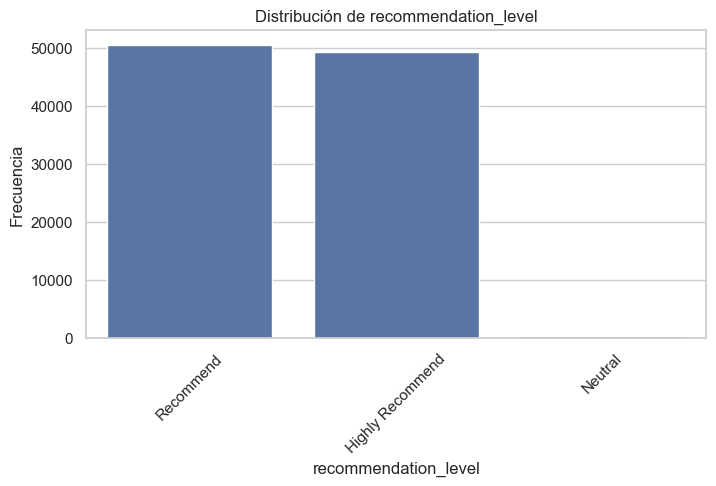

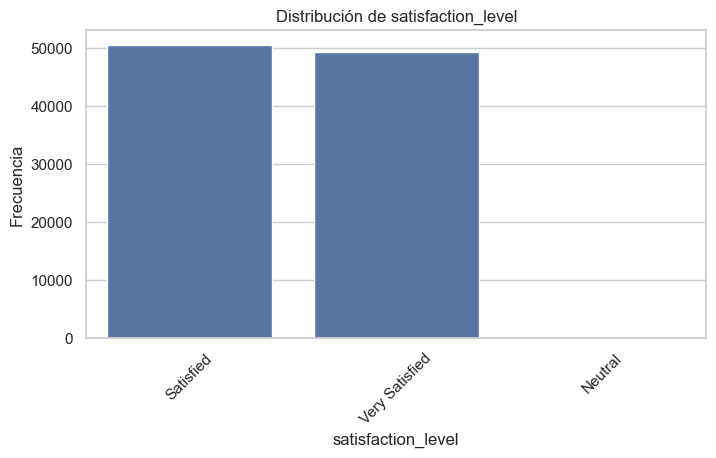

In [27]:
# Se selecciona variables categóricas con pocas categorías para graficar
columnas_categoricas_graficos = [
    "gender",
    "age_group",
    "attraction_level",
    "is_group_tour",
    "season",
    "is_holiday",
    "recommendation_level",
    "satisfaction_level"
]

for col in columnas_categoricas_graficos:
    plt.figure(figsize=(8, 4))
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45)
    plt.show()

Los gráficos de barras permiten observar la distribución de las variables categóricas principales. 
Se observa que el género está bastante equilibrado. 
El grupo etario con mayor presencia es `56+`. 
La mayoría de las atracciones son de nivel 4A o 5A. 
Además, cerca del 70% de los registros corresponde a turistas que no realizaron viajes grupales.

### **Visualizaciones del Análisis Exploratorio**

#### **Distribución de la variable objetivo**

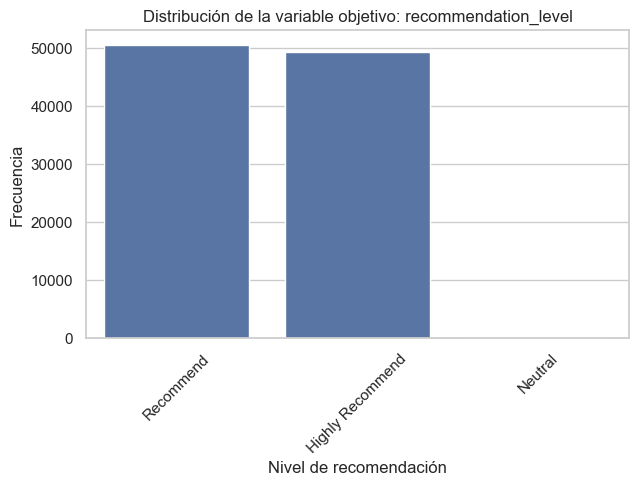

In [28]:
# Distribución de la variable objetivo
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="recommendation_level",
    order=df["recommendation_level"].value_counts().index
)

plt.title("Distribución de la variable objetivo: recommendation_level")
plt.xlabel("Nivel de recomendación")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

In [30]:

# Porcentaje de cada clase
df["recommendation_level"].value_counts(normalize=True) * 100

recommendation_level
Recommend           50.518
Highly Recommend    49.241
Neutral              0.241
Name: proportion, dtype: float64

La variable objetivo `recommendation_level` indica el nivel de recomendación entregado por el turista. 
El dataset presenta principalmente dos categorías: `Recommend` y `Highly Recommend`. 
La categoría `Neutral` aparece en una proporción muy baja.

Esto representa un desafío importante para un futuro modelo de clasificación, ya que existe un fuerte desbalance de clases. 
Un modelo podría tener dificultades para aprender correctamente la clase minoritaria `Neutral`.

#### **Mapa de calor de correlaciones**

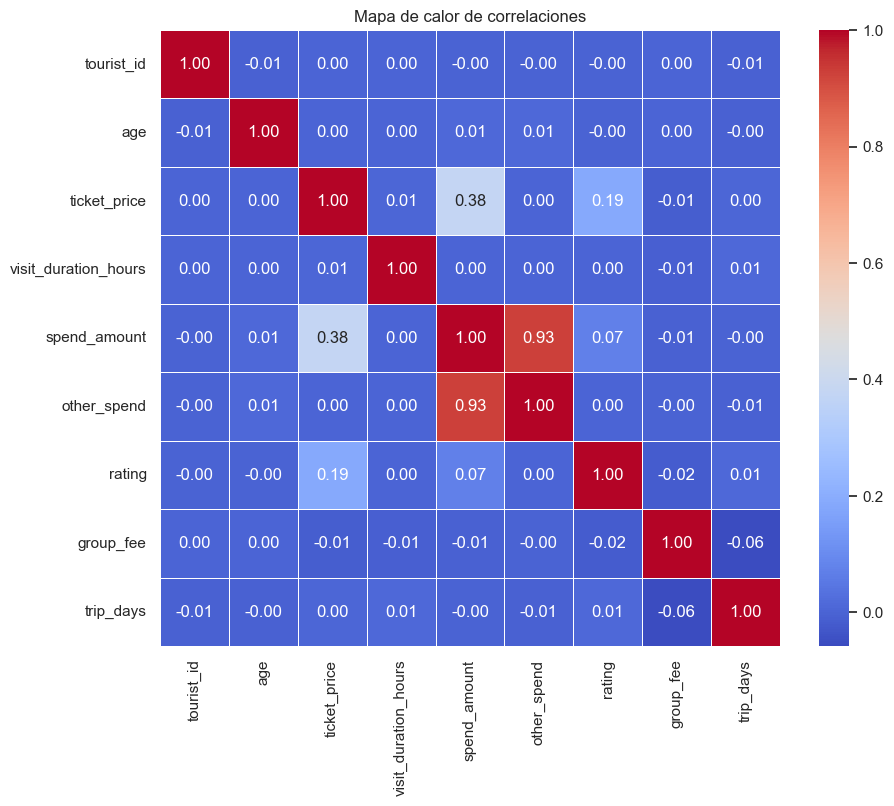

In [31]:
# Mapa de calor de correlaciones entre variables numéricas
plt.figure(figsize=(10, 8))

correlacion = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Mapa de calor de correlaciones")
plt.show()

El mapa de calor permite revisar la relación entre variables numéricas. 
Se observa una relación positiva entre `ticket_price` y `rating`, lo que podría indicar que las atracciones con mayor precio tienden a recibir mejores evaluaciones. 
También se observa relación entre `ticket_price` y `spend_amount`, ya que el gasto total incluye el precio de entrada y otros gastos asociados.

In [32]:
# Correlación de variables numéricas con rating
df.select_dtypes(include=np.number).corr()["rating"].sort_values(ascending=False)

rating                  1.000000
ticket_price            0.188038
spend_amount            0.073955
trip_days               0.011122
other_spend             0.003992
visit_duration_hours    0.001390
tourist_id             -0.000126
age                    -0.003480
group_fee              -0.017731
Name: rating, dtype: float64

La variable `rating` tiene su mayor correlación positiva con `ticket_price`, aunque esta relación no es extremadamente alta. 
Esto indica que el nivel de satisfacción o evaluación turística probablemente depende de varios factores y no solo del precio de entrada.

### **Análisis específico del dataset**

#### **Rating promedio según nivel de atracción**

In [33]:
# Rating promedio según nivel de atracción
rating_nivel = df.groupby("attraction_level")["rating"].mean().sort_values(ascending=False)

rating_nivel

attraction_level
5A    4.583583
4A    4.318006
3A    3.806068
Name: rating, dtype: float64

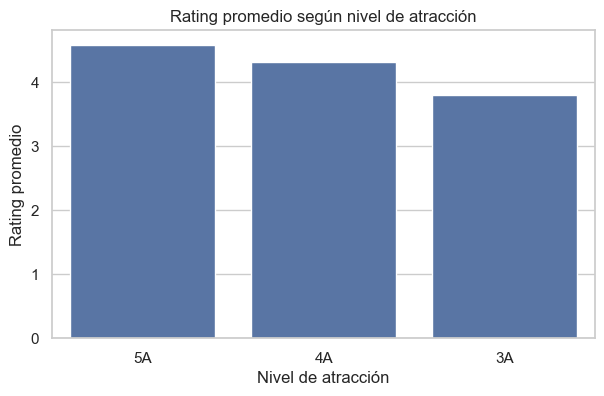

In [34]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=rating_nivel.index,
    y=rating_nivel.values
)

plt.title("Rating promedio según nivel de atracción")
plt.xlabel("Nivel de atracción")
plt.ylabel("Rating promedio")
plt.show()

Se observa que las atracciones de nivel 5A presentan el rating promedio más alto, seguidas por las atracciones 4A y luego 3A. 
Esto sugiere que el nivel turístico de la atracción está relacionado con la evaluación de los visitantes.

#### **Rating promedio según temporada**

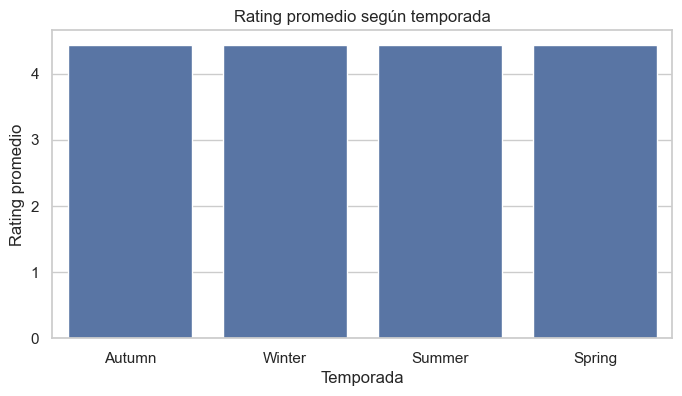

In [35]:
# Rating promedio según temporada
rating_temporada = df.groupby("season")["rating"].mean().sort_values(ascending=False)

rating_temporada
plt.figure(figsize=(8, 4))

sns.barplot(
    x=rating_temporada.index,
    y=rating_temporada.values
)

plt.title("Rating promedio según temporada")
plt.xlabel("Temporada")
plt.ylabel("Rating promedio")
plt.show()

El rating promedio es bastante similar entre temporadas. 
Esto indica que la temporada no parece generar grandes diferencias en la evaluación promedio de las atracciones turísticas.

#### **Rating promedio según tipo de viaje**

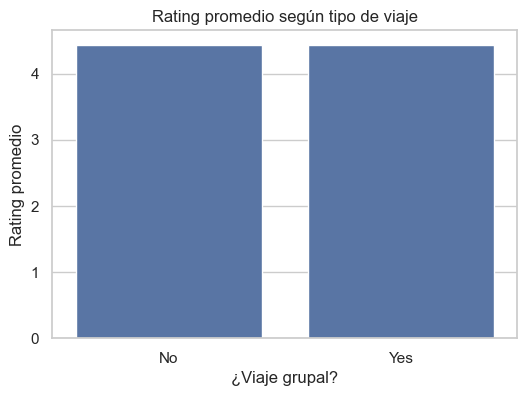

In [36]:
# Rating promedio según tipo de viaje
rating_grupo = df.groupby("is_group_tour")["rating"].mean().sort_values(ascending=False)

rating_grupo
plt.figure(figsize=(6, 4))

sns.barplot(
    x=rating_grupo.index,
    y=rating_grupo.values
)

plt.title("Rating promedio según tipo de viaje")
plt.xlabel("¿Viaje grupal?")
plt.ylabel("Rating promedio")
plt.show()

El rating promedio entre turistas que viajan en grupo y turistas que no viajan en grupo es muy similar. 
Esto sugiere que el tipo de viaje, por sí solo, no explica grandes diferencias en la evaluación turística.

#### **Rating promedio según feriado**

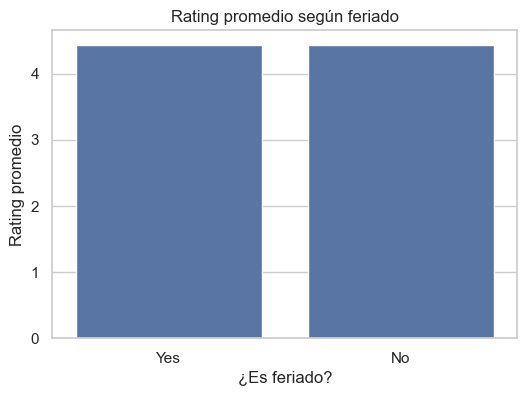

In [37]:
# Rating promedio según feriado
rating_feriado = df.groupby("is_holiday")["rating"].mean().sort_values(ascending=False)

rating_feriado
plt.figure(figsize=(6, 4))

sns.barplot(
    x=rating_feriado.index,
    y=rating_feriado.values
)

plt.title("Rating promedio según feriado")
plt.xlabel("¿Es feriado?")
plt.ylabel("Rating promedio")
plt.show()

El rating promedio es prácticamente igual entre visitas realizadas en feriado y visitas realizadas en días normales. 
Por lo tanto, el feriado no parece modificar de forma importante la evaluación promedio de los turistas.

#### **Rating promedio por categoría de atracción**

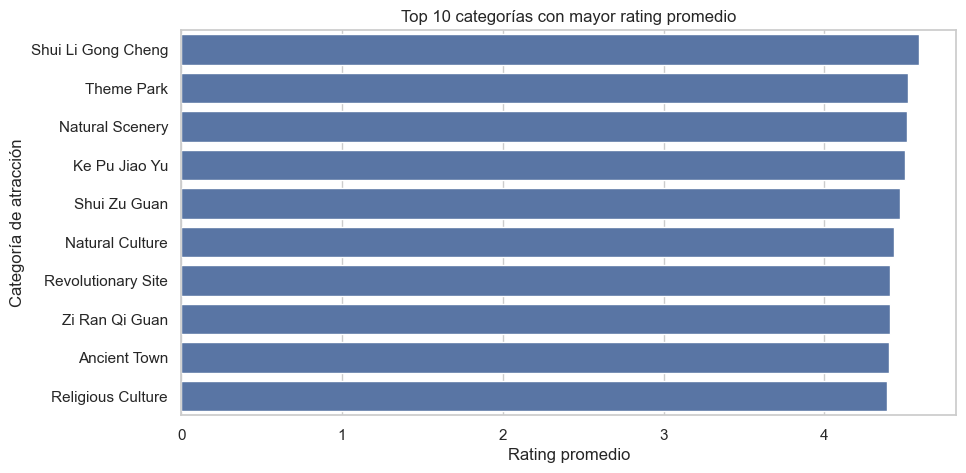

In [38]:
# Rating promedio por categoría de atracción
rating_categoria = df.groupby("attraction_category")["rating"].mean().sort_values(ascending=False).head(10)

rating_categoria
plt.figure(figsize=(10, 5))

sns.barplot(
    x=rating_categoria.values,
    y=rating_categoria.index
)

plt.title("Top 10 categorías con mayor rating promedio")
plt.xlabel("Rating promedio")
plt.ylabel("Categoría de atracción")
plt.show()

El análisis por categoría muestra que algunas categorías de atracciones presentan un rating promedio más alto que otras. 
Esto puede ser útil para entender qué tipos de atracciones generan mayor satisfacción y recomendación entre los turistas.


#### **Relación entre Satisfacción y Recomendación**

In [39]:
# Tabla cruzada entre recomendación y satisfacción
pd.crosstab(df["recommendation_level"], df["satisfaction_level"])

satisfaction_level,Neutral,Satisfied,Very Satisfied
recommendation_level,,,
Highly Recommend,0,0,49241
Neutral,241,0,0
Recommend,0,50518,0


Se observa que `recommendation_level` y `satisfaction_level` tienen una relación directa. 
La categoría `Highly Recommend` coincide con `Very Satisfied`, `Recommend` coincide con `Satisfied` y `Neutral` coincide con `Neutral`.

Esto indica que ambas variables entregan prácticamente la misma información. 
Por lo tanto, si se usa `recommendation_level` como variable objetivo en un futuro modelo, no conviene usar `satisfaction_level` como variable predictora, porque produciría fuga de información.

#### **Comparación de Promedios según Nivel de Recomendación**

In [40]:
# Promedios de variables numéricas según nivel de recomendación
df.groupby("recommendation_level")[columnas_numericas].mean().round(2)

,tourist_id,age,ticket_price,visit_duration_hours,spend_amount,other_spend,rating,group_fee,trip_days
recommendation_level,,,,,,,,,
Highly Recommend,4741.06,44.16,89.90,4.5,265.53,175.63,4.74,3016.34,4.02
Neutral,4653.99,43.24,0.00,4.4,153.03,153.03,3.30,2756.03,4.07
Recommend,4754.83,44.30,72.28,4.5,246.08,173.80,4.14,3074.57,3.97


Al comparar los promedios según el nivel de recomendación, se pueden observar diferencias entre las categorías. 
Los registros con mayor recomendación tienden a presentar ratings más altos. 
También pueden existir diferencias en precio de entrada, gasto total y duración de la visita.

Este análisis ayuda a identificar qué variables podrían estar relacionadas con el nivel de recomendación turística.

#### **Boxplot de rating según nivel de atracción**

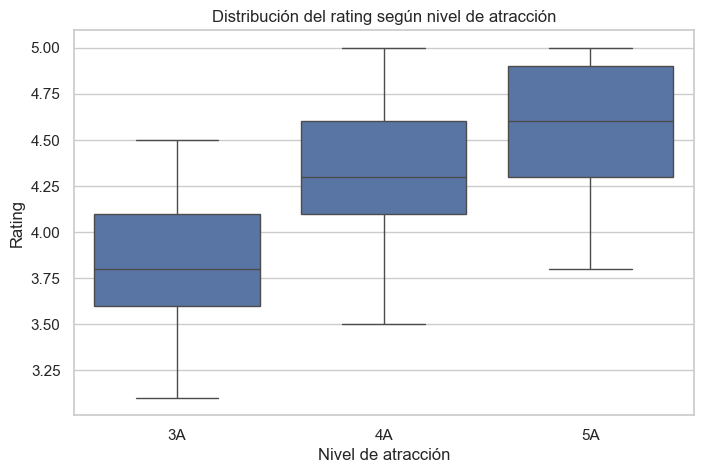

In [41]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="attraction_level",
    y="rating",
    order=["3A", "4A", "5A"]
)

plt.title("Distribución del rating según nivel de atracción")
plt.xlabel("Nivel de atracción")
plt.ylabel("Rating")
plt.show()

Este boxplot permite comparar la distribución del rating según el nivel de atracción. 
Se observa que las atracciones 5A tienden a concentrarse en valores de rating más altos, mientras que las atracciones 3A presentan evaluaciones más bajas.

# **Resumen de Hallazgos**

El dataset de recomendación turística contiene 100.000 registros y 25 variables. Cada registro representa una visita o interacción turística. El conjunto de datos incluye información del turista, características de la atracción, gasto, duración de visita, rating, satisfacción y nivel de recomendación.

El dataset no presenta registros duplicados exactos. Sin embargo, la variable `tourist_id` se repite, lo cual no representa un error, ya que un mismo turista puede haber realizado varias visitas.

Se identificaron valores nulos en las variables `group_fee`, `trip_days`, `main_spots` y `transport_mode`. Estos nulos están asociados a turistas que no realizaron viajes grupales, por lo que se consideran nulos estructurales y no errores de carga.

Durante la revisión de variables categóricas se detectó que la variable `season` contiene la categoría `Chun Ji`, correspondiente a primavera. Se recomienda reemplazarla por `Spring` para mantener consistencia en el idioma de las categorías.

En las variables numéricas se detectaron posibles outliers en `ticket_price`, `spend_amount` y `rating`. Estos valores parecen plausibles dentro del contexto turístico, por lo que no se recomienda eliminarlos automáticamente.

La variable objetivo propuesta es `recommendation_level`, que permite plantear un problema de clasificación multiclase. Sin embargo, existe un fuerte desbalance en la categoría `Neutral`, que representa solo cerca del 0,24% de los registros.

También se observa que `recommendation_level` y `satisfaction_level` contienen prácticamente la misma información. Por esta razón, si se utiliza `recommendation_level` como variable objetivo, no se debería usar `satisfaction_level` como variable predictora para evitar fuga de información.

El análisis muestra que las atracciones de nivel 5A tienen un rating promedio mayor que las atracciones 4A y 3A. Esto sugiere que el nivel de la atracción está relacionado con la evaluación y recomendación de los turistas.

En general, el dataset es adecuado para trabajar una problemática de recomendación turística o clasificación del nivel de recomendación, aunque presenta desafíos importantes como variables categóricas de alta cardinalidad, nulos estructurales y desbalance de clases.
# **Diagnóstico del Dataset**

El dataset presenta una buena calidad general, ya que no contiene registros duplicados exactos y tiene una gran cantidad de observaciones. 
Además, cuenta con variables variadas relacionadas con el turista, la atracción, el gasto y la experiencia de visita.

Uno de los principales desafíos es la presencia de valores nulos estructurales en variables asociadas a viajes grupales. Estos nulos no deben ser tratados como errores, ya que aparecen cuando el turista no realizó un viaje grupal.

Otro desafío importante es la alta cantidad de categorías en variables como `attraction_name`, `city`, `province` y `main_spots`. Estas variables pueden ser útiles para análisis turísticos, pero podrían complicar una futura etapa de modelamiento si no se codifican correctamente.

También se observa un fuerte desbalance en la variable objetivo `recommendation_level`, especialmente porque la categoría `Neutral` tiene muy pocos registros. Esto puede afectar el rendimiento de un modelo de clasificación.

Finalmente, se detecta una relación directa entre `recommendation_level` y `satisfaction_level`, lo que implica que se debe evitar usar ambas variables al mismo tiempo en un modelo predictivo para no generar fuga de información.
# **Problemática Seleccionada**

La problemática seleccionada para este dataset es un problema de **clasificación multiclase**.

El objetivo será predecir el nivel de recomendación de una atracción turística para un visitante, utilizando características del turista, de la atracción y del comportamiento de visita.

La variable objetivo será `recommendation_level`, que contiene tres categorías:

- `Highly Recommend`
- `Recommend`
- `Neutral`

Este problema es relevante porque puede ayudar a plataformas turísticas, agencias de viaje o sistemas de recomendación a identificar qué experiencias tienen mayor probabilidad de ser recomendadas por los visitantes.

# **Justificación de la Elección**

Se elige este dataset porque presenta una problemática clara y actual dentro del área de turismo y sistemas de recomendación. 
El análisis del nivel de recomendación permite estudiar qué factores influyen en la experiencia del turista y en la probabilidad de recomendar una atracción.

El dataset es interesante porque combina información demográfica, geográfica, económica y de comportamiento. 
Además, tiene un tamaño considerable de 100.000 registros, lo que permite realizar un análisis exploratorio más completo.

También presenta desafíos importantes para ciencia de datos, como variables categóricas de alta cardinalidad, valores nulos estructurales, posibles outliers y desbalance de clases en la variable objetivo.

Por estas razones, este dataset es una buena opción para desarrollar un problema de clasificación multiclase o como base para un sistema de recomendación turística.